In [2]:
!pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]




[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

In [ ]:
#LOAD DATASET
df = pd.read_csv("attrition.csv")

In [ ]:
#VIEW DATASET
print(df.head())

print(df.shape)

print(df.info())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [7]:
#CHECK MISSING VALUES
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
#REMOVE DUPLICATES
df = df.drop_duplicates()

print(df.duplicated().sum())

0


Attrition
No     1233
Yes     237
Name: count, dtype: int64


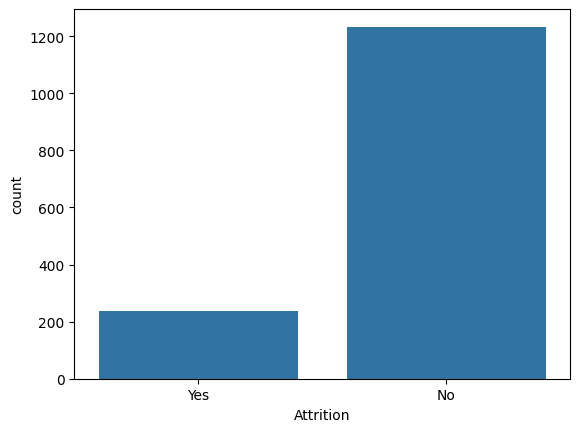

In [9]:
#CHECK TARGET BALANCE
print(df['Attrition'].value_counts())

sns.countplot(x='Attrition', data=df)

plt.show()

In [10]:
#SEPARATE FEATURES & TARGET
X = df.drop('Attrition', axis=1)

y = df['Attrition']

In [11]:
#TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
#CHECK TRAIN/TEST BALANCE
print(y_train.value_counts())

print(y_test.value_counts())

Attrition
No     986
Yes    190
Name: count, dtype: int64
Attrition
No     247
Yes     47
Name: count, dtype: int64


In [13]:
#ONE HOT ENCODING
X_train = pd.get_dummies(
    X_train,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    drop_first=True
)

In [14]:
#ALIGN TRAIN & TEST COLUMNS
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

In [15]:
#FEATURE SCALING
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [16]:
# APPLY SMOTE BALANCING
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

In [17]:
#VERIFY BALANCING
print(y_train.value_counts())

Attrition
No     986
Yes    986
Name: count, dtype: int64


In [18]:
#CHECK FINAL SHAPES
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(1972, 47)
(294, 47)
(1972,)
(294,)


In [19]:
print(y_train.value_counts())

Attrition
No     986
Yes    986
Name: count, dtype: int64


In [25]:
#FEATURE SELECTION
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

var_thresh = VarianceThreshold(threshold=0)

X_train = var_thresh.fit_transform(X_train)

X_test = var_thresh.transform(X_test)
selector = SelectKBest(
    score_func=f_classif,
    k=20
)

X_train_selected = selector.fit_transform(
    X_train,
    y_train
)

X_test_selected = selector.transform(
    X_test
)

In [27]:
# Feature names after encoding

feature_names = pd.get_dummies(
    X,
    drop_first=True
).columns

# Remove constant feature names

feature_names = feature_names[
    var_thresh.get_support()
]

# Final selected feature names

selected_features = feature_names[
    selector.get_support()
]

print("Selected Features:")

print(selected_features)

Selected Features:
Index(['Age', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'StockOptionLevel',
       'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently',
       'JobRole_Laboratory Technician', 'JobRole_Manager',
       'JobRole_Manufacturing Director', 'JobRole_Research Director',
       'JobRole_Sales Representative', 'MaritalStatus_Married',
       'MaritalStatus_Single', 'OverTime_Yes'],
      dtype='str')


In [28]:
print(X_train_selected.shape)
print(X_test_selected.shape)

(1972, 20)
(294, 20)
